In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load orders data and convert order_date from text to datetime
orders = pd.read_csv("orders.csv", parse_dates=["order_date"])

# Load customer data and convert signup_date from text to datetime
customers = pd.read_csv("customers.csv", parse_dates=["signup_date"])

# Load product information
products = pd.read_csv("products.csv")

# Calculate revenue for each order line
# Revenue = price × quantity
orders["revenue"] = orders["price"] * orders["quantity"]

# Join orders with customer information using customer_id
df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

# Join the result with product information using product_id
# suffixes prevent duplicate column names from causing confusion
df = df.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("", "_prod")
)

# Replace missing brand values with "Unknown"
# This prevents missing values from affecting later analysis
df["brand"] = df["brand"].fillna("Unknown")

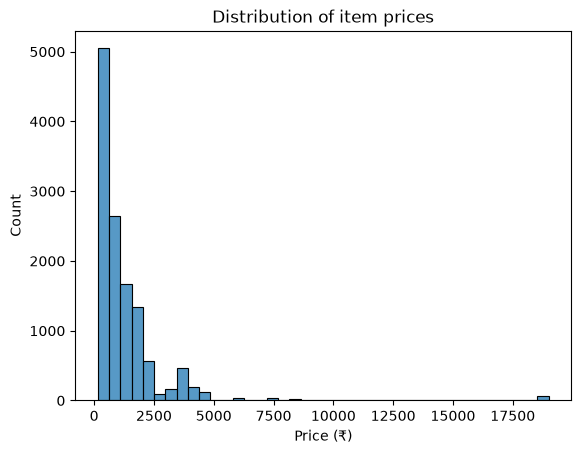

In [10]:
# Create a histogram to understand how product prices are distributed
# bins=40 divides the price range into 40 groups
sns.histplot(df["price"], bins=40)

# Label the x-axis
plt.xlabel("Price (₹)")

# Add a title to the chart
plt.title("Distribution of item prices")

# Display the chart
plt.show()

In [11]:
# Calculate and print the average price
print("mean:", round(df["price"].mean(), 2))

# Calculate and print the middle value (median)
print("median:", df["price"].median())

# Calculate and print the skewness of the price distribution
print("skew:", round(df["price"].skew(), 2))

mean: 1274.49
median: 776.0
skew: 6.44


In [12]:
# Select the numeric columns we want to compare
num_cols = ["price", "quantity", "revenue", "rating"]

# Calculate the correlation matrix
# round(2) keeps the results to two decimal places
correlation = df[num_cols].corr().round(2)

# Display the correlation matrix
correlation

,price,quantity,revenue,rating
price,1.00,-0.21,0.90,0.09
quantity,-0.21,1.00,0.07,-0.02
revenue,0.90,0.07,1.00,0.08
rating,0.09,-0.02,0.08,1.00


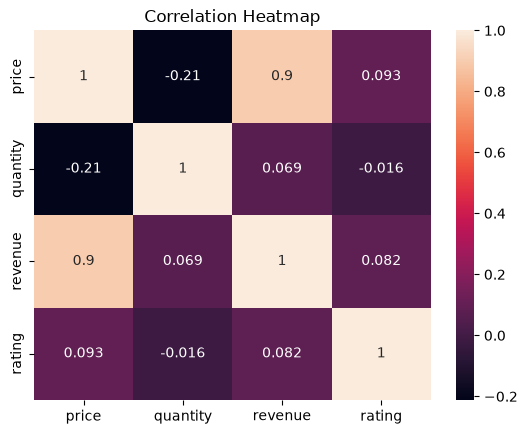

In [13]:
# Calculate correlations between the selected numeric columns
corr_matrix = df[num_cols].corr()

# Display the correlation matrix as a heatmap
# annot=True displays the correlation values inside each cell
sns.heatmap(corr_matrix, annot=True)

# Add a title to the heatmap
plt.title("Correlation Heatmap")

# Display the chart
plt.show()

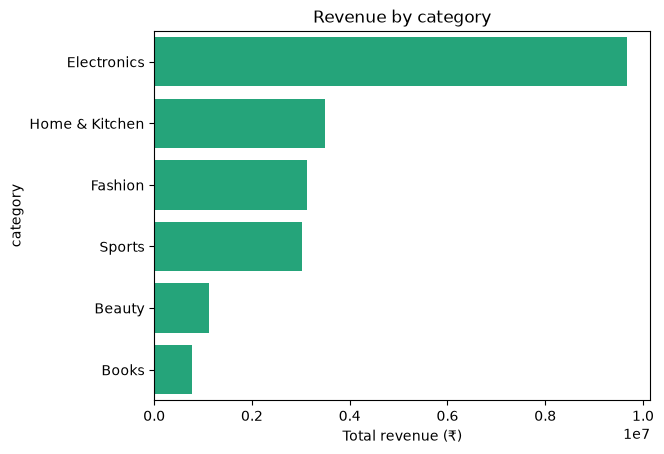

In [14]:
# Group the data by product category
# Then calculate total revenue for each category
cat_rev = df.groupby("category")["revenue"].sum()

# Sort categories from highest revenue to lowest revenue
cat_rev = cat_rev.sort_values(ascending=False)

# Create a horizontal bar chart
# x = revenue values
# y = category names
sns.barplot(
    x=cat_rev.values,
    y=cat_rev.index,
    color="#10B981"
)

# Label the x-axis
plt.xlabel("Total revenue (₹)")

# Add a chart title
plt.title("Revenue by category")

# Display the chart
plt.show()

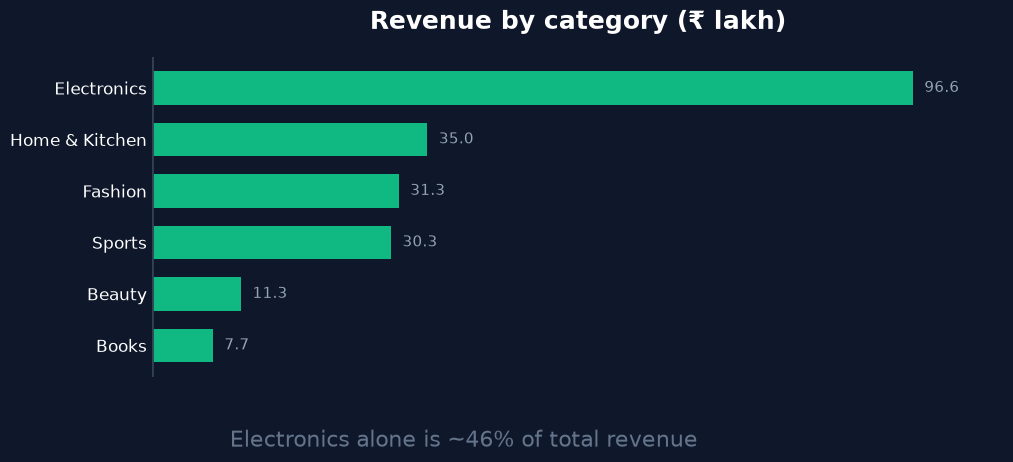

In [20]:
# ------------------------------
# Revenue by Category — Key Chart
# ------------------------------

# Calculate total revenue for each category
cat_rev = (
    df.groupby("category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

# Create the figure
fig, ax = plt.subplots(figsize=(12, 5))

# Set dark background
fig.patch.set_facecolor("#0F172A")
ax.set_facecolor("#0F172A")

# Create horizontal bar chart
bars = ax.barh(
    cat_rev.index,
    cat_rev.values / 100000,   # Convert revenue to ₹ lakh
    color="#10B981",
    height=0.65
)

# Reverse order so highest revenue appears at the top
ax.invert_yaxis()

# Add revenue values at the end of each bar
for bar, value in zip(bars, cat_rev.values / 100000):
    ax.text(
        bar.get_width() + 1.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=11,
        color="#94A3B8"
    )

# Add chart title
ax.set_title(
    "Revenue by category (₹ lakh)",
    fontsize=18,
    fontweight="bold",
    color="white",
    pad=20
)

# Label the x-axis
ax.set_xlabel("")

# Remove x-axis tick labels
ax.set_xticks([])

# Style category labels
ax.tick_params(
    axis="y",
    colors="white",
    labelsize=12,
    length=0
)

# Remove chart borders/spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add a subtle vertical baseline
ax.axvline(
    x=0,
    color="#334155",
    linewidth=2
)

# Calculate Electronics' percentage of total revenue
electronics_pct = (
    cat_rev["Electronics"] / cat_rev.sum()
) * 100

# Add explanatory text at the bottom
fig.text(
    0.5,
    0.04,
    f"Electronics alone is ~{electronics_pct:.0f}% of total revenue",
    ha="center",
    fontsize=16,
    color="#64748B"
)

# Add some space around the chart
ax.set_xlim(0, cat_rev.max() / 100000 * 1.12)

# Adjust layout
plt.subplots_adjust(
    left=0.24,
    right=0.95,
    top=0.82,
    bottom=0.18
)

# Display the chart
plt.show()

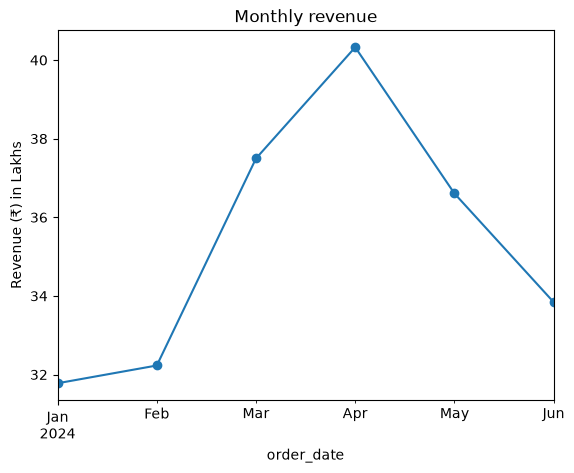

In [24]:
# Set order_date as the DataFrame index
# This allows us to perform time-based operations
monthly = (
    df.set_index("order_date")

    # Resample the data by month-end
    # "ME" means Month End
    ["revenue"]
    .resample("ME")

    # Calculate total revenue for each month
    .sum()/100000  # Convert to ₹ Lakhs
    
)

# Plot monthly revenue as a line chart
# marker="o" adds a point for each month
monthly.plot(marker="o")

# Label the y-axis
plt.ylabel("Revenue (₹) in Lakhs")

# Add a chart title
plt.title("Monthly revenue")

# Display the chart
plt.show()

In [25]:
# Convert each customer's signup date into a signup month
# Example: 2024-05-15 → 2024-05
df["signup_month"] = df["signup_date"].dt.to_period("M")

# Group customers by their signup month
# Then calculate the average revenue per line item
cohort = (
    df.groupby("signup_month")["revenue"]
      .mean()
      .round(0)
)

# Display the last four signup cohorts
cohort.tail(4)

signup_month
2024-02    2029.0
2024-03    1799.0
2024-04    1374.0
2024-05    1449.0
Freq: M, Name: revenue, dtype: float64